In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_excel("../data/raw/all_article_data.xlsx")

In [3]:
df.head()

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN


In [4]:
df1= pd.read_excel("../data/processed/clean_article_data.xlsx")

In [5]:
df1.head()

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN


In [6]:
df1["method_code"] = df1["method"].map({"polarization": 0,"EIS": 1})

In [7]:
X= df1[['temperature_K','qe_concentration_ppm','method_code']]

In [8]:
y= df1['IE_percent']

In [9]:
X.head()

,temperature_K,qe_concentration_ppm,method_code
0,298,0,0
1,298,200,0
2,298,400,0
3,298,600,0
4,298,800,0


In [10]:
y.head()

0     0.0
1    67.8
2    69.0
3    79.5
4    90.4
Name: IE_percent, dtype: float64

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [12]:
lm=LinearRegression()

In [13]:
lm.fit(X_train,y_train)

LinearRegression()

In [14]:
pred_lm=lm.predict(X_test)

In [15]:
pred_lm

array([93.15699151, 62.95220522, 40.67934412, 68.81678364, 83.91917679,
       15.09346519, 58.33329786, 37.36632629, 45.29825148])

In [16]:
y_test

18    91.0
16    81.0
37    47.0
25    74.0
26    81.0
32     0.0
20    72.0
1     67.8
33    61.2
Name: IE_percent, dtype: float64

In [17]:
mae=mean_absolute_error(y_test,pred_lm)
print('MAE:',mae)

MAE: 12.191491652707915


In [18]:
rmse=np.sqrt(mean_squared_error(y_test,pred_lm))
print('RMSE:',rmse)

RMSE: 14.904805581066412


In [19]:
r2=r2_score(y_test,pred_lm)
print('R2:',r2)

R2: 0.6598636237785224


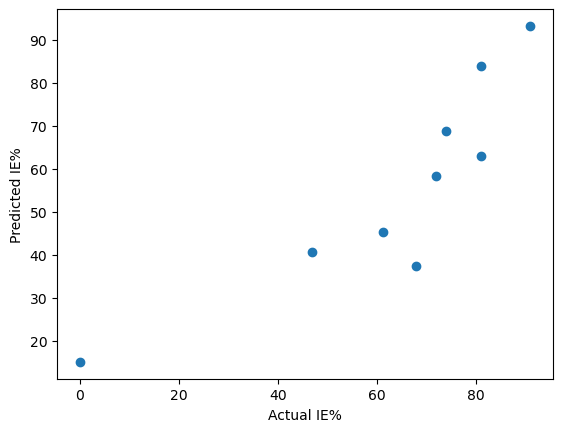

In [20]:
plt.scatter(y_test, pred_lm)
plt.xlabel('Actual IE%')
plt.ylabel('Predicted IE%')
plt.show()

In [21]:
lm.score(X_test,y_test)

0.6598636237785224

### RandomForest

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
rfr=RandomForestRegressor(n_estimators=100,random_state=101)

In [24]:
rfr.fit(X_train,y_train)

RandomForestRegressor(random_state=101)

In [25]:
pred_rf=rfr.predict(X_test)

In [26]:
rfr.score(X_test,y_test)

0.8500709508932489

In [27]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [28]:
print('MAE:',mean_absolute_error(y_test,pred_rf))

MAE: 6.870222222222214


In [29]:
print('MSE:',mean_squared_error(y_test,pred_rf))

MSE: 97.92314133333319


In [30]:
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred_rf)))

RMSE: 9.895612226301775


### XGBoost

In [31]:
from xgboost import XGBRegressor

In [32]:
xgb=XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=101)

In [33]:
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=101, ...)

In [34]:
pred_xgb=xgb.predict(X_test)

In [35]:
xgb.score(X_test,y_test)

0.9736788027166413

In [36]:
print('Model Score R2:', xgb.score(X_test, y_test))
print('MAE:', mean_absolute_error(y_test, pred_xgb))
print('MSE:', mean_squared_error(y_test, pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_xgb)))
print('R2:', r2_score(y_test, pred_xgb))

Model Score R2: 0.9736788027166413
MAE: 2.5459831747743826
MSE: 17.191160332149522
RMSE: 4.1462224171104864
R2: 0.9736788027166413


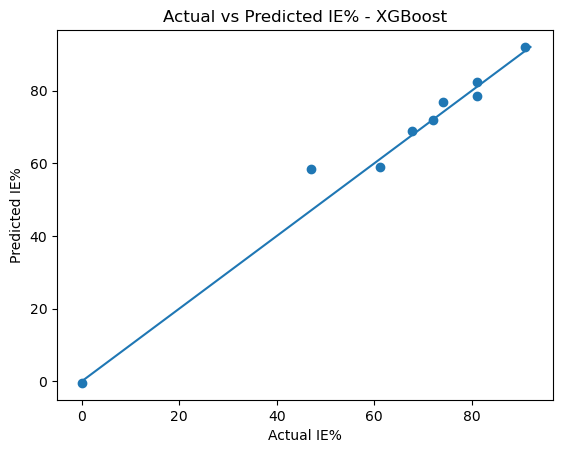

In [37]:
plt.scatter(y_test, pred_xgb)
min_value = min(y_test.min(), pred_xgb.min())
max_value = max(y_test.max(), pred_xgb.max())
plt.plot([min_value, max_value], [min_value, max_value])
plt.xlabel("Actual IE%")
plt.ylabel("Predicted IE%")
plt.title("Actual vs Predicted IE% - XGBoost")
plt.savefig("../reports/xgboost_actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [38]:
def get_metrics(model_name,y_test,predictions):
    return {'model':model_name,
            'MAE':mean_absolute_error(y_test,predictions),
            'MSE':mean_squared_error(y_test,predictions),
            'RMSE':np.sqrt(mean_squared_error(y_test,predictions)),
            'R2':r2_score(y_test,predictions)}

In [39]:
results=[]
results.append(get_metrics('Linear Regression',y_test,pred_lm))
results.append(get_metrics('Random Forest',y_test,pred_rf))
results.append(get_metrics('XGBoost',y_test,pred_xgb))

In [40]:
results_df=pd.DataFrame(results)
results_df=results_df.round(3)
results_df.to_csv('../reports/model_computer_results.csv',index=False)

In [41]:
results_df

,model,MAE,MSE,RMSE,R2
0,Linear Regression,12.191,222.153,14.905,0.660
1,Random Forest,6.870,97.923,9.896,0.850
2,XGBoost,2.546,17.191,4.146,0.974


In [42]:
models={"Linear Regression":LinearRegression(),
        "Random Forest":RandomForestRegressor(n_estimators=100,random_state=101),
        "XGBoost":XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=101)
        }
cv_results=[]
for model_name,model in models.items():
    scores=cross_val_score(model,X,y,cv=5,scoring="r2")
    cv_results.append({"model":model_name,"mean_R2":scores.mean(),"std_R2":scores.std()})
    cv_results_df=pd.DataFrame(cv_results)
    cv_results_df=cv_results_df.round(3)

In [43]:
cv_results_df

,model,mean_R2,std_R2
0,Linear Regression,0.770,0.115
1,Random Forest,0.802,0.342
2,XGBoost,0.830,0.307
